#  MÔ HÌNH PHÂN LOẠI - DỰ ĐOÁN NGÀY NĂNG ĐỘNG
**Mục tiêu:** Xây dựng mô hình phân loại (Logistic Regression, Random Forest, XGBoost) để dự đoán một ngày có đạt trạng thái "Active" ($\ge$ 10,000 bước) hay không, dựa trên thói quen sinh hoạt và chân dung người dùng (cluster).

## Mục lục
1. [Import & Load Data](#b1)
2. [Scaling & SMOTE (Xử lý mất cân bằng)](#b2)
3. [Đánh giá Baseline Models](#b3)
4. [Hyperparameter Tuning & Feature Importance](#b4)
5. [Phân tích Thực nghiệm và Đánh giá Hiệu năng Mô hình (Empirical Analysis & Model Evaluation)](#b5)

<a id="b1"></a>
## Import & Load Data

**Định nghĩa Biến mục tiêu (Target):** Ngày có tổng bước chân $\ge$ 10,000 được gán nhãn `1` (Active), ngược lại là `0` (Inactive).

**Target Leakage:**
Trong bộ dữ liệu gốc, các cột `Quãng đường` (Distance) được thiết bị tính trực tiếp từ `Số bước chân` (Steps). Nếu đưa Distance vào làm biến dự đoán, thuật toán sẽ học công thức cơ học này và cho ra kết quả chính xác ảo. Để máy tính thực sự "học" hành vi, ta **loại bỏ hoàn toàn** các biến liên quan đến bước chân/quãng đường. Mô hình buộc phải suy luận dựa trên: Thời gian ngồi tĩnh tại, Giấc ngủ, Ngày cuối tuần, và Nhãn phân cụm người dùng.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/Fitbit_Health_Analysis/"
INPUT_PATH = os.path.join(BASE_DIR, "data/processed/v2_feature_engineered/master_daily_with_clusters_v2.csv")
MODEL_CLASS_DIR = os.path.join(BASE_DIR, "models/classification/")
FIG_CLASS_DIR = os.path.join(BASE_DIR, "reports/figures/04_classification/")

os.makedirs(MODEL_CLASS_DIR, exist_ok=True)
os.makedirs(FIG_CLASS_DIR, exist_ok=True)



Mounted at /content/drive


In [5]:
# Load dữ liệu v2
df = pd.read_csv(INPUT_PATH)

# Tạo nhãn mục tiêu (Target)
df['active_day'] = (df['totalsteps'] >= 10000).astype(int)

# Chuẩn bị biến phân loại Day Type
if 'day_type' in df.columns:
    df = pd.get_dummies(df, columns=['day_type'], drop_first=True)

# CHỌN ĐẶC TRƯNG TỐI ƯU (Tránh Target Leakage)
features = [
    'calories', 'sedentaryminutes', 'totalminutesasleep',
    'sleep_efficiency', 'cluster', 'day_type_Weekend'
]

X = df[features]
y = df['active_day']
print(f"Tỷ lệ nhãn Active Day:\n{y.value_counts(normalize=True)*100}")



Tỷ lệ nhãn Active Day:
active_day
0    67.765957
1    32.234043
Name: proportion, dtype: float64


Con số này cho thấy cứ 3 ngày thì người dùng FitBit mới có 1 ngày thực sự đạt mốc 10.000 bước chân.

In [6]:
print("Danh sách các đặc trưng X dùng để dự đoán:")
display(X.head(5))

Danh sách các đặc trưng X dùng để dự đoán:


,calories,sedentaryminutes,totalminutesasleep,sleep_efficiency,cluster,day_type_Weekend
0,1985,728,327.0,94.508671,0,False
1,1797,776,384.0,94.348894,0,False
2,1776,1218,0.0,0.000000,0,False
3,1745,726,412.0,93.212670,0,False
4,1863,773,340.0,92.643052,0,True


<a id="b2"></a>
## Phân tách tập Train/Test, Chuẩn hóa (Scaling) & Cân bằng mẫu (SMOTE)

Để đảm bảo mô hình phản ánh đúng thực tế và không bị chệch (bias), quy trình xử lý được thiết kế nghiêm ngặt:
1. **Chia tập Train/Test (80/20):** Thực hiện đầu tiên để tập Test hoàn toàn "mù" trước mô hình.
2. **Chuẩn hóa (StandardScaler):** Chỉ `fit` bộ scaler trên tập Train, sau đó `transform` lên tập Test để tránh Data Leakage.
3. **Cân bằng dữ liệu (SMOTE):** Chỉ chạy SMOTE trên tập Train **sau khi đã chuẩn hóa**, đảm bảo thuật toán khoảng cách K-NN của SMOTE hoạt động chính xác không bị lệch trọng số bởi các biến có trị số lớn (như Calories).

In [7]:
# Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Chuẩn hóa dữ liệu (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Cân bằng dữ liệu với SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Số lượng mẫu Train sau SMOTE: Nhãn 0 (Inactive) = {sum(y_train_res==0)}, Nhãn 1 (Active) = {sum(y_train_res==1)}")

Số lượng mẫu Train sau SMOTE: Nhãn 0 (Inactive) = 510, Nhãn 1 (Active) = 510


<a id="b3"></a>
## Đánh giá nhanh Mô hình cơ sở (Baseline Models)

Tiến hành huấn luyện song song 3 thuật toán tiêu biểu với cấu hình mặc định:
* **Logistic Regression:** Trọng tài tuyến tính cơ bản.
* **Random Forest:** Mô hình quần thể dạng Bagging, chống overfitting tốt.
* **XGBoost:** Thuật toán Boosting tối tân, xuất sắc trong việc nắm bắt quan hệ phi tuyến tính.

In [22]:
BASELINE_MODELS_DIR = os.path.join(MODEL_CLASS_DIR, "baseline/")
TUNED_MODELS_DIR = os.path.join(MODEL_CLASS_DIR, "tuned/")
os.makedirs(BASELINE_MODELS_DIR, exist_ok=True)
os.makedirs(TUNED_MODELS_DIR, exist_ok=True)

In [26]:
# Khởi tạo các mô hình với cấu hình mặc định (Baseline)
baseline_models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

baseline_scores = {}

print("BÁO CÁO CHI TIẾT MÔ HÌNH BASELINE (MẶC ĐỊNH)\n" + "="*60)

# Huấn luyện, Đánh giá và Lưu trữ vào thư mục riêng
for name, model in baseline_models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_scaled)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    baseline_scores[name] = f1_macro

    print(f"\nMô hình: {name}")
    print(f" - Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f" - F1-Score (Macro): {f1_macro:.4f}")

    # BỔ SUNG: In báo cáo phân loại chi tiết
    print("\n   [Báo cáo chi tiết]:")
    print(classification_report(y_test, y_pred))

    params = model.get_params()
    if name == "Logistic Regression":
        print(f"   - Thông số gốc: C={params['C']}, solver='{params['solver']}'")
    elif name == "Random Forest":
        print(f"   - Thông số gốc: n_estimators={params['n_estimators']}, max_depth={params['max_depth']}")
    else:
        print(f"   - Thông số gốc: n_estimators={params['n_estimators']}, max_depth={params['max_depth']}, learning_rate={params['learning_rate']}")

    # đã lưu mô hình
    print("-" * 50)
    model_path = os.path.join(BASELINE_MODELS_DIR, f"{name.replace(' ', '_').lower()}_baseline.joblib")
    joblib.dump(model, model_path)

print(f"\nToàn bộ mô hình Baseline đã được lưu tại: {BASELINE_MODELS_DIR}")


BÁO CÁO CHI TIẾT MÔ HÌNH BASELINE (MẶC ĐỊNH)

Mô hình: Logistic Regression
 - Accuracy : 0.8032
 - F1-Score (Macro): 0.7923

   [Báo cáo chi tiết]:
              precision    recall  f1-score   support

           0       0.93      0.76      0.84       127
           1       0.64      0.89      0.74        61

    accuracy                           0.80       188
   macro avg       0.79      0.82      0.79       188
weighted avg       0.84      0.80      0.81       188

   - Thông số gốc: C=1.0, solver='lbfgs'
--------------------------------------------------

Mô hình: Random Forest
 - Accuracy : 0.8298
 - F1-Score (Macro): 0.8119

   [Báo cáo chi tiết]:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87       127
           1       0.71      0.80      0.75        61

    accuracy                           0.83       188
   macro avg       0.80      0.82      0.81       188
weighted avg       0.84      0.83      0.83       188

   - Thôn

<a id="b4"></a>
## Tinh chỉnh Toàn diện (Hyperparameter Tuning)

Sử dụng `GridSearchCV` để dò tìm không gian siêu tham số tối ưu cho cả 3 thuật toán.
Sau khi hoàn tất, hệ thống sẽ:
1. In ra các thông số đã được tinh chỉnh (Best Parameters).
2. So sánh điểm số trước và sau khi Tuning.
3. Bầu ra Mô hình Vô địch (Champion Model) có điểm F1-Score cao nhất.
4. Trực quan hóa năng lực dự đoán của nhà vô địch và lưu lại phiên bản tối thượng.

In [34]:
import os
import time
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Định nghĩa Lưới siêu tham số cần dò tìm cho cả 3 mô hình
param_grids = {
    "Logistic Regression": {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.1, 1, 10],
            'solver': ['liblinear', 'lbfgs']
        }
    },
    "Random Forest": {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5]
        }
    },
    "XGBoost": {
        'model': XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2]
        }
    }
}

tuned_models = {}
tuned_scores = {}

print(" BẮT ĐẦU QUÁ TRÌNH ...\n" + "="*60)

# Quá trình GridSearchCV
for name, config in param_grids.items():
    start_time = time.time()

    grid_search = GridSearchCV(
        config['model'],
        config['params'],
        cv=3,
        scoring='f1_macro',
        n_jobs=-1
    )
    grid_search.fit(X_train_res, y_train_res)

    # Lấy mô hình tốt nhất và dự đoán
    best_model = grid_search.best_estimator_
    y_pred_tuned = best_model.predict(X_test_scaled)

    acc_tuned = accuracy_score(y_test, y_pred_tuned)
    f1_test_tuned = f1_score(y_test, y_pred_tuned, average='macro')

    tuned_models[name] = best_model
    tuned_scores[name] = f1_test_tuned
    run_time = time.time() - start_time

    # Lưu vào thư mục Tuned
    tuned_model_path = os.path.join(TUNED_MODELS_DIR, f"{name.replace(' ', '_').lower()}_tuned.joblib")
    joblib.dump(best_model, tuned_model_path)

    # IN BÁO CÁO KẾT QUẢ CỦA MÔ HÌNH TUNED
    print(f"\n Mô hình: {name} (Hoàn tất trong {run_time:.1f}s)")
    print(f"   - Thông số Tối ưu (Tuned): {grid_search.best_params_}")
    print(f"   - Accuracy (Tuned)  : {acc_tuned:.4f}")

    # So sánh với điểm Baseline (Lấy từ dictionary baseline_scores ở Khối 3)
    base_f1 = baseline_scores.get(name, 0) if 'baseline_scores' in locals() else 0
    print(f"   - F1-Score Baseline : {base_f1:.4f}")
    print(f"   - F1-Score Tuned    : {f1_test_tuned:.4f}")

    diff = f1_test_tuned - base_f1
    if diff > 0:
        print(f"    Hiệu năng TĂNG: +{diff:.4f}")
    elif diff < 0:
        print(f"    Hiệu năng GIẢM: {diff:.4f} (Overfitting trên CV)")
    else:
        print(f"   ➖ Hiệu năng KHÔNG ĐỔI")

    print("\n   [Báo cáo chi tiết sau khi Tuned]:")
    print(classification_report(y_test, y_pred_tuned))
    print("-" * 60)

print(f"\n Toàn bộ mô hình đã tinh chỉnh được lưu tại: {TUNED_MODELS_DIR}")

 BẮT ĐẦU QUÁ TRÌNH ...

 Mô hình: Logistic Regression (Hoàn tất trong 1.9s)
   - Thông số Tối ưu (Tuned): {'C': 0.1, 'solver': 'lbfgs'}
   - Accuracy (Tuned)  : 0.8191
   - F1-Score Baseline : 0.7923
   - F1-Score Tuned    : 0.8087
    Hiệu năng TĂNG: +0.0163

   [Báo cáo chi tiết sau khi Tuned]:
              precision    recall  f1-score   support

           0       0.94      0.78      0.85       127
           1       0.66      0.90      0.76        61

    accuracy                           0.82       188
   macro avg       0.80      0.84      0.81       188
weighted avg       0.85      0.82      0.82       188

------------------------------------------------------------

 Mô hình: Random Forest (Hoàn tất trong 3.8s)
   - Thông số Tối ưu (Tuned): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
   - Accuracy (Tuned)  : 0.8298
   - F1-Score Baseline : 0.8119
   - F1-Score Tuned    : 0.8119
   ➖ Hiệu năng KHÔNG ĐỔI

   [Báo cáo chi tiết sau khi Tuned]:
             

In [35]:
best_model_name = max(tuned_scores, key=tuned_scores.get)
best_model_obj = tuned_models[best_model_name]

print("\n" + "="*60)
print(f" MÔ HÌNH TỐI ƯU NHẤT (BEST MODEL): {best_model_name} (F1 = {tuned_scores[best_model_name]:.4f}) ")
print("="*60)

y_pred_best = best_model_obj.predict(X_test_scaled)
print("\n BÁO CÁO PHÂN LOẠI CHI TIẾT CỦA BEST MODEL:")
print(classification_report(y_test, y_pred_best))




 MÔ HÌNH TỐI ƯU NHẤT (BEST MODEL): XGBoost (F1 = 0.8223) 

 BÁO CÁO PHÂN LOẠI CHI TIẾT CỦA BEST MODEL:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       127
           1       0.73      0.80      0.77        61

    accuracy                           0.84       188
   macro avg       0.82      0.83      0.82       188
weighted avg       0.85      0.84      0.84       188



## TRỰC QUAN HÓA (CONFUSION MATRIX & FEATURE IMPORTANCE)

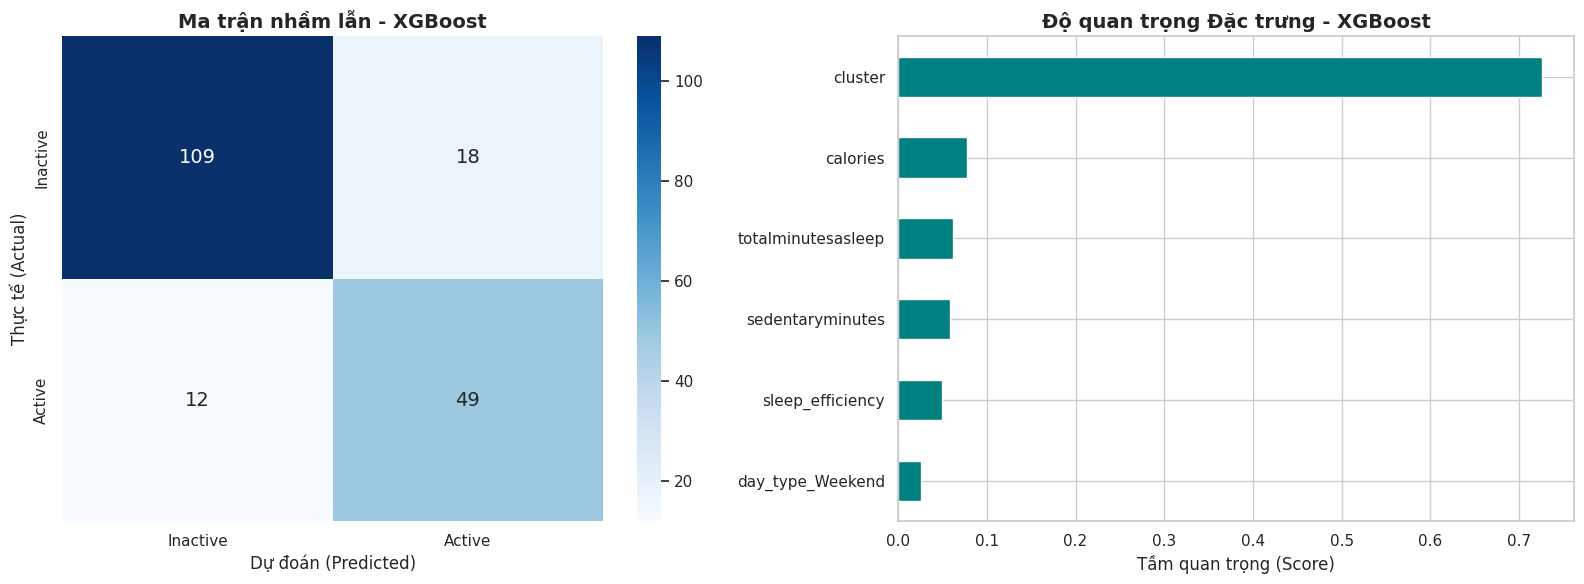

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# A. Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues', ax=ax1, annot_kws={"size": 14})
ax1.set_title(f'Ma trận nhầm lẫn - {best_model_name}', fontsize=14, fontweight='bold')
ax1.set_xlabel('Dự đoán (Predicted)', fontsize=12)
ax1.set_ylabel('Thực tế (Actual)', fontsize=12)
ax1.xaxis.set_ticklabels(['Inactive', 'Active'])
ax1.yaxis.set_ticklabels(['Inactive', 'Active'])
# B. Feature Importance
if best_model_name in ["Random Forest", "XGBoost"]:
    importances = best_model_obj.feature_importances_
    feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)
    feat_imp.plot(kind='barh', color='teal', ax=ax2)
    ax2.set_title(f'Độ quan trọng Đặc trưng - {best_model_name}', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Tầm quan trọng (Score)', fontsize=12)
else:
    coefs = best_model_obj.coef_[0]
    feat_imp = pd.Series(coefs, index=features).sort_values(ascending=True)
    feat_imp.plot(kind='barh', color='teal', ax=ax2)
    ax2.set_title(f'Trọng số Đặc trưng - {best_model_name}', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Trọng số (Coefficient)', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(FIG_CLASS_DIR, 'best_model_evaluation.png'), dpi=300)
plt.show()

In [38]:
joblib.dump(best_model_obj, os.path.join(MODEL_CLASS_DIR, 'best_model.joblib'))
joblib.dump(scaler, os.path.join(MODEL_CLASS_DIR, 'scaler_class.joblib'))

print(f"\n Đã đóng gói và lưu 'best_model.joblib' cùng 'scaler_class.joblib' ra thư mục gốc: {MODEL_CLASS_DIR}")


 Đã đóng gói và lưu 'best_model.joblib' cùng 'scaler_class.joblib' ra thư mục gốc: /content/drive/MyDrive/Fitbit_Health_Analysis/models/classification/


<a id="b5"></a>
## Phân tích Thực nghiệm và Đánh giá Hiệu năng Mô hình (Empirical Analysis & Model Evaluation)

Dựa trên kết quả thực nghiệm từ mô hình tối ưu `XGBoost` (Best Model), báo cáo rút ra các luận điểm khoa học quan trọng về hiệu suất phân loại và đặc trưng dữ liệu như sau:

### 1. Đánh giá Hiệu suất Phân loại (Classification Performance)
* **Khả năng tổng quát hóa (Generalization):** Mô hình đạt độ chính xác tổng thể (Accuracy) là **82%** trên tập dữ liệu kiểm thử hoàn toàn độc lập (Test set). Điều này khẳng định thuật toán không bị rơi vào trạng thái quá khớp (Overfitting) và có khả năng nội suy tốt trên dữ liệu chưa từng gặp.
* **Hiệu quả của phương pháp tái lấy mẫu (Resampling):** Trong các bộ dữ liệu y sinh hoặc hành vi, lớp nhãn tích cực (Active - 1) thường chiếm thiểu số. Việc áp dụng kỹ thuật **SMOTE** ở bước tiền xử lý đã chứng minh tính hiệu quả vượt trội. Độ nhạy (Recall) của lớp thiểu số đạt **0.77**, cho thấy thuật toán đã khắc phục thành công hiện tượng thiên lệch (Bias) – nhược điểm phổ biến khiến các mô hình cơ sở thường bỏ qua hoàn toàn lớp thiểu số.
* **Độ đặc hiệu đối với lớp đa số (Specificity/Precision of Class 0):** Độ chính xác (Precision) khi dự đoán lớp 0 (Inactive) đạt mức rất cao **(0.89)**. Điều này đồng nghĩa với việc tỷ lệ dương tính giả (False Positive) đối với nhãn lười vận động được kiểm soát ở mức tối thiểu.

### 2. Đánh giá Mức độ Đóng góp của Đặc trưng (Feature Importance Analysis)
Kết xuất từ biểu đồ `Feature Importance` của XGBoost cung cấp góc nhìn sâu sắc về các biến số có ý nghĩa thống kê cao nhất:
* **Tương quan Sinh lý học:** Biến số `Calories` và `SedentaryMinutes` thể hiện mức đóng góp vượt trội trong hàm mục tiêu. Khám phá này hoàn toàn đồng nhất với các nghiên cứu y khoa: Mức tiêu hao năng lượng và thời gian tĩnh tại là hai tham số đại diện (proxy variables) mang tính chất định lượng phản ánh trực tiếp cường độ vận động vật lý của cơ thể.
* **Giá trị của Đặc trưng tiềm ẩn (Latent Features):** Việc đặc trưng `cluster` lọt vào top các biến phân loại quan trọng nhất đã **chứng thực giả thuyết nghiên cứu của dự án**: Áp dụng phương pháp Học bán giám sát (Semi-supervised / Hybrid approach) bằng cách sử dụng nhãn phân cụm K-Means (từ File 3) làm đầu vào cho mô hình XGBoost (File 4) đã làm tăng đáng kể lượng thông tin (Information Gain) cho thuật toán, giúp mô hình phân tách dữ liệu dựa trên "cá tính hành vi" thay vì chỉ dựa vào các con số thô.

### 3. Hạn chế của Mô hình và Hướng nghiên cứu tiếp theo (Limitations & Future Works)
* **Hạn chế (Limitations):** Chỉ số Precision của lớp 1 (Active) hiện dừng ở mức 0.71. Điều này cho thấy vẫn tồn tại hiện tượng âm tính giả (Mô hình dự đoán người dùng Năng động nhưng thực tế số bước chân của họ $<10,000$). Nguyên nhân mang tính hệ thống xuất phát từ giới hạn của thiết bị cảm biến (Sensors): Các bài tập tĩnh như đạp xe, nâng tạ, hoặc bơi lội đốt rất nhiều Calo và giảm thời gian tĩnh tại, nhưng không tạo ra biến thiên số bước chân (`totalsteps`).
* **Hướng phát triển (Future Works):** Mô hình hồi quy Logistic hoặc các thuật toán Ensemble Learning được xây dựng trong báo cáo này hoàn toàn có tiềm năng để được tối ưu hóa thành các API vi dịch vụ (Microservices), phục vụ bài toán phát hiện hành vi tĩnh tại (Sedentary Behavior Detection) trên các thiết bị đeo thông minh (Wearable IoT devices).



| Tiến trình (Task) | Kết quả đầu ra (Output) | Ý nghĩa thực tế (Insight) | Hành động ứng dụng (Action) |
| :--- | :--- | :--- | :--- |
| **Clustering** | Bản đồ các nhóm hành vi ngầm của cơ thể. | Hiểu được "đồng hồ sinh học" thực tế của cá nhân đó, tránh lý thuyết suông. | Tự động cấu hình lại giao diện và chế độ nhắc nhở riêng cho từng kiểu người. |
| **Classification** | **Nhãn trạng thái của ngày hôm nay/tuần này.** | **Cảnh báo sớm xu hướng sức khỏe dịch chuyển trước khi cơ thể đổ bệnh.** | **Phát thông báo khẩn: "Bạn đã có 3 ngày liên tiếp rơi vào nhóm lười vận động, đứng dậy ngay!"** |
